# Classifiers for Chemistry Data
We will again use the Delaney solubility dataset as an example. This has a quantification of solubility, which we will turn into a classification by setting a threshold for soluble or insoluble

# Install packages
Only run if you do not already have these packages

In [53]:
%pip install rdkit
%pip install pandas
%pip install scikit-learn
%pip install matplotlib

^C
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Load and process data

In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, DataStructs
import numpy as np

#method we will use to convert fingerprint to an array that can be used later with scikit learn
def mol_to_fp_array(mol, radius=2, nBits=2048):
    if mol is None:
        return None
    
    fpgen_morgan = AllChem.GetMorganGenerator(radius=radius,fpSize=nBits)
    fp = fpgen_morgan.GetFingerprint(mol)
    
    arr = np.zeros((nBits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

df = pd.read_csv("delaney.csv")

#let's set a log solubility of -2 as the cutoff between soluble and insoluble
df['soluble'] = df["measured log(solubility:mol/L)"] > -2

#calculate descriptors and add them to the dataframe
#Note - it can often help the model performance to scale the data within a standard range and/or to a normal distribution
#We will discuss how to do this in a future set of example code
df["mol"] = df["SMILES"].apply(Chem.MolFromSmiles)
df["hba"] = df["mol"].apply(lambda m: Descriptors.NumHAcceptors(m) if m is not None else pd.NA)
df["hbd"] = df["mol"].apply(lambda m: Descriptors.NumHDonors(m) if m is not None else pd.NA)
df["mw"] = df["mol"].apply(lambda m: Descriptors.MolWt(m) if m is not None else pd.NA)

#calculate fingerprints and add them to the dataframe

df["fp"] = df["mol"].apply(lambda m: mol_to_fp_array(m) if m is not None else pd.NA)

#this will let us see the beginning of the table
df.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,soluble,mol,hba,hbd,mw,fp
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,False,<rdkit.Chem.rdchem.Mol object at 0x0000016D06E...,0,0,167.850,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,False,<rdkit.Chem.rdchem.Mol object at 0x0000016D06E...,0,0,133.405,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,True,<rdkit.Chem.rdchem.Mol object at 0x0000016D06E...,0,0,167.850,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,True,<rdkit.Chem.rdchem.Mol object at 0x0000016D06E...,0,0,133.405,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,False,<rdkit.Chem.rdchem.Mol object at 0x0000016D06E...,0,0,187.375,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


# Split data into training and test
We will split our data into training and test data. We will do this randomly for now. Note that for testing that better assesses model generlizability, you would want to split by scaffold.

In [2]:
from sklearn.model_selection import train_test_split

#this will put 20% of the data into the test set
#note that the random state needs to be set to make sure it is split consistently between runs
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

# Logistic Regression model

Train Accuracy:  0.8197
Train Precision: 0.7363
Train Recall:    0.6837
Train Balanced Accuracy:    0.6837
AUPRC (Average Precision): 0.7826
AUROC: 0.8808


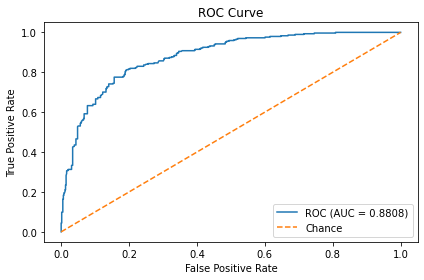

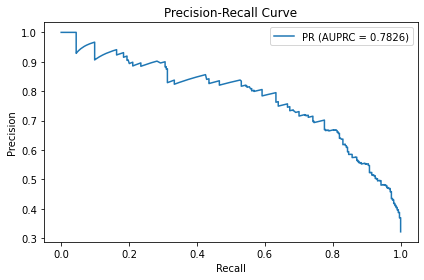

In [3]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    average_precision_score,
    roc_curve,
    auc,
    precision_recall_curve,
    roc_auc_score
)

# Try logistic regression using H-bond donor and molecular weight as features
log_classifier = LogisticRegression()
# For scikit learn, fit them to data using the fit function, then list x data or y data
# the x and y data could be matrices you have already prepared or you can extract the columns from a pandas dataframe, as shown
log_classifier.fit(train_df[["hbd","mw"]],train_df["soluble"])

# Let's calculate metrics for our training data
predicted_train = log_classifier.predict(train_df[["hbd","mw"]]) #this will predict class labels
predicted_train_prob = log_classifier.predict_proba(train_df[["hbd","mw"]]) #this will give probabilities

acc = accuracy_score(train_df["soluble"], predicted_train)
prec = precision_score(train_df["soluble"], predicted_train, zero_division=0)
rec = recall_score(train_df["soluble"], predicted_train, zero_division=0)
balanced_acc = balanced_accuracy_score(train_df["soluble"], predicted_train)
fpr, tpr, _ = roc_curve(train_df["soluble"], predicted_train_prob[:,1])
roc_auc = roc_auc_score(train_df["soluble"], predicted_train_prob[:,1])

#these metrics use probabilities rather than class
auprc = average_precision_score(train_df["soluble"], predicted_train_prob[:,1])
    

print(f"Train Accuracy:  {acc:.4f}")
print(f"Train Precision: {prec:.4f}")
print(f"Train Recall:    {rec:.4f}")
print(f"Train Balanced Accuracy:    {rec:.4f}")
print(f"AUPRC (Average Precision): {auprc:.4f}")
print(f"AUROC: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Precision-Recall
pr_prec, pr_rec, _ = precision_recall_curve(train_df["soluble"], predicted_train_prob[:,1])

plt.figure()
plt.plot(pr_rec, pr_prec, label=f"PR (AUPRC = {auprc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

Test Accuracy:  0.7904
Test Precision: 0.6707
Test Recall:    0.7237
Test Balanced Accuracy:    0.7237
AUPRC (Average Precision): 0.7813
AUROC: 0.8744


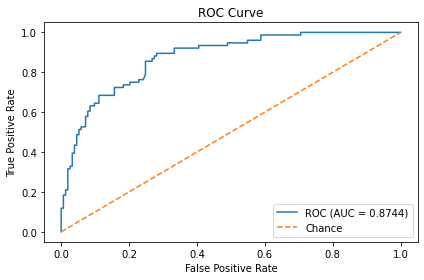

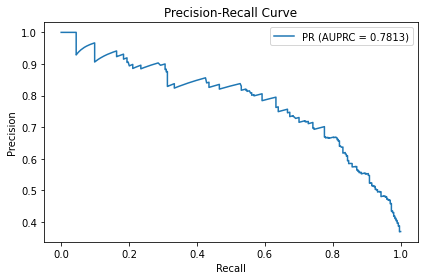

In [11]:
# lets look at the test accuracy
predicted_test = log_classifier.predict(test_df[["hbd","mw"]]) #this will predict class labels
predicted_test_prob = log_classifier.predict_proba(test_df[["hbd","mw"]]) #this will give probabilities

acc = accuracy_score(test_df["soluble"], predicted_test)
prec = precision_score(test_df["soluble"], predicted_test, zero_division=0)
rec = recall_score(test_df["soluble"], predicted_test, zero_division=0)
balanced_acc = balanced_accuracy_score(test_df["soluble"], predicted_test)
fpr, tpr, _ = roc_curve(test_df["soluble"], predicted_test_prob[:,1])
roc_auc = roc_auc_score(test_df["soluble"], predicted_test_prob[:,1])

#these metrics use probabilities rather than class
auprc = average_precision_score(test_df["soluble"], predicted_test_prob[:,1])
    

print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall:    {rec:.4f}")
print(f"Test Balanced Accuracy:    {rec:.4f}")
print(f"AUPRC (Average Precision): {auprc:.4f}")
print(f"AUROC: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Precision-Recall
pr_prec, pr_rec, _ = precision_recall_curve(train_df["soluble"], predicted_train_prob[:,1])

plt.figure()
plt.plot(pr_rec, pr_prec, label=f"PR (AUPRC = {auprc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()



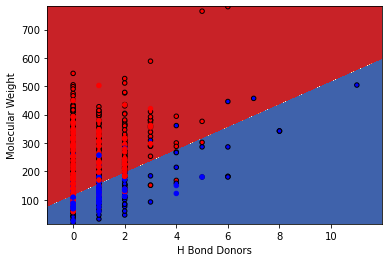

In [5]:
# Let's look at the decision boundary
#we will plot hdb feature on the x axis and molecular weight on the y
from matplotlib.colors import ListedColormap

n_classes = 2
cmap = plt.cm.RdYlBu
plot_step = 0.02  # fine step width for decision surface contours

plt.figure()
x_min, x_max = df["hbd"].min() - 1, df["hbd"].max() + 1
y_min, y_max = df["mw"].min() - 1, df["mw"].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step)
)
Z = log_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z, cmap=cmap)

#plot training data with black edge
plt.scatter(
            train_df["hbd"],
            train_df["mw"],
            c=train_df["soluble"],
            cmap=ListedColormap(["r", "y", "b"]),
            edgecolor="k",
            s=20,
)
plt.scatter(
            test_df["hbd"],
            test_df["mw"],
            c=test_df["soluble"],
            cmap=ListedColormap(["r", "y", "b"]),
            s=20,
)
plt.xlabel("H Bond Donors")
plt.ylabel("Molecular Weight")

plt.show()

 # Random Forest Classifier

Train Balanced Accuracy:    0.9555
Test Balanced Accuracy:    0.8096


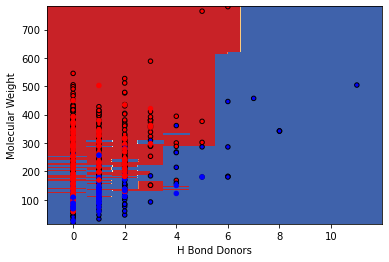

In [6]:
# let's try the same thing with a random forest classifer
# we will skip showing all of the metrics and just focus on balanced accuracy
#try changing n_estimators and seeing how that changes the results
from sklearn.ensemble import RandomForestClassifier

random_forest_classifier = RandomForestClassifier(n_estimators=10)
random_forest_classifier.fit(train_df[["hbd","mw"]],train_df["soluble"])

# Let's calculate metrics for our training data
predicted_train = random_forest_classifier.predict(train_df[["hbd","mw"]]) #this will predict class labels
predicted_train_prob = random_forest_classifier.predict_proba(train_df[["hbd","mw"]]) #this will give probabilities

balanced_acc = balanced_accuracy_score(train_df["soluble"], predicted_train)
print(f"Train Balanced Accuracy:    {balanced_acc:.4f}")

predicted_test = random_forest_classifier.predict(test_df[["hbd","mw"]]) #this will predict class labels
predicted_test_prob = random_forest_classifier.predict_proba(test_df[["hbd","mw"]]) #this will give probabilities

balanced_acc = balanced_accuracy_score(test_df["soluble"], predicted_test)
print(f"Test Balanced Accuracy:    {balanced_acc:.4f}")

n_classes = 2
cmap = plt.cm.RdYlBu
plot_step = 0.02  # fine step width for decision surface contours

plt.figure()
x_min, x_max = df["hbd"].min() - 1, df["hbd"].max() + 1
y_min, y_max = df["mw"].min() - 1, df["mw"].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step)
)
Z = random_forest_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z, cmap=cmap)

#plot training data with black edge
plt.scatter(
            train_df["hbd"],
            train_df["mw"],
            c=train_df["soluble"],
            cmap=ListedColormap(["r", "y", "b"]),
            edgecolor="k",
            s=20,
)
plt.scatter(
            test_df["hbd"],
            test_df["mw"],
            c=test_df["soluble"],
            cmap=ListedColormap(["r", "y", "b"]),
            s=20,
)
plt.xlabel("H Bond Donors")
plt.ylabel("Molecular Weight")

plt.show()


# Hyperparameter optimization

In [12]:
# finally let's try using the whole fingerprint
# and optimizing the hyperparameters using GridSearchCV for a RandomForest Classifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score

#recreate the random forest classifier without any hyperparameters set
random_forest_classifier = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

#define the grid of parameters you want to test the combinations of
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]  # helpful if imbalanced
}

#set cross validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#set up the grid,we need to give it our classifier, our grid, scoring, and cross validation method 
grid = GridSearchCV(
    estimator=random_forest_classifier,
    param_grid=param_grid,
    scoring={
        "accuracy": "accuracy",
        "roc_auc": "roc_auc",
        "auprc": "average_precision"
    },
    refit="auprc",      # refit best model based on AUPRC
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# fit the training data
# note because train_df["fp"] has an array rather than individual values we have to use np.stack(train_dif["fp"].values)
# to get the values as a matrix for scikit learn
grid.fit(np.stack(train_df["fp"].values), train_df["soluble"])

# best model
print("Best parameters:")
print(grid.best_params_)

print("\nBest CV AUPRC:")
print(grid.best_score_)

best_model = grid.best_estimator_

#evaluate on train data
y_pred = best_model.predict(np.stack(train_df["fp"].values))
y_proba = best_model.predict_proba(np.stack(train_df["fp"].values))[:, 1]

print("\nTest Classification Report:")
print(classification_report(train_df["soluble"], y_pred))

print("Test ROC AUC:", roc_auc_score(train_df["soluble"], y_proba))
print("Test AUPRC:", average_precision_score(train_df["soluble"], y_proba))

#evaluate on test data 
y_pred = best_model.predict(np.stack(test_df["fp"].values))
y_proba = best_model.predict_proba(np.stack(test_df["fp"].values))[:, 1]

print("\nTest Classification Report:")
print(classification_report(test_df["soluble"], y_pred))

print("Test ROC AUC:", roc_auc_score(test_df["soluble"], y_proba))
print("Test AUPRC:", average_precision_score(test_df["soluble"], y_proba))

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 349 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 632 tasks      | elapsed:  7.0min
[Parallel(n_jobs=-1)]: Done 997 tasks      | elapsed: 10.5min
[Parallel(n_jobs=-1)]: Done 1442 tasks      | elapsed: 15.4min
[Parallel(n_jobs=-1)]: Done 1969 tasks      | elapsed: 23.3min
[Parallel(n_jobs=-1)]: Done 2160 out of 2160 | elapsed: 25.6min finished


Best parameters:
{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}

Best CV AUPRC:
0.8660947307351521

Test Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       621
        True       1.00      0.99      1.00       294

    accuracy                           1.00       915
   macro avg       1.00      1.00      1.00       915
weighted avg       1.00      1.00      1.00       915

Test ROC AUC: 0.9999616593819493
Test AUPRC: 0.99984179718399

Test Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.92      0.88       153
        True       0.80      0.67      0.73        76

    accuracy                           0.83       229
   macro avg       0.82      0.79      0.80       229
weighted avg       0.83      0.83      0.83       229

Test ROC AUC: 0.9328775369797042
T

# Support Vector Machines

In [4]:
from sklearn.svm import SVC
# now we will try classification with a support vector classifer, again we will just compare train and test accuracy to save time
# some details on SVC hyperparameters. C is a hyperparameter that controls trade off between training error and decision boundary width/simplicity
# the kernel defines the possible shape of the decision boundary, it applies a transformation to the data (if you use poly as the kernel, you can also set the degree of the polynomial)
# the gamma parameter controls the effect of support vectors on the decision boundary
# if we want to be able to calcualte probabilities to do ROC curves, you need to add a probability=True argument
# SVC is slower than the other classifiers so we will just train it on the beginning of the dataset as an example
svc = SVC(C=1.0, kernel='linear', gamma='scale')
svc.fit(train_df[["hbd","mw"]],train_df["soluble"])

# Let's calculate metrics for our training data
predicted_train = svc.predict(train_df[["hbd","mw"]]) #this will predict class labels

balanced_acc = balanced_accuracy_score(train_df["soluble"], predicted_train)
print(f"Train Balanced Accuracy:    {balanced_acc:.4f}")

predicted_test = svc.predict(test_df[["hbd","mw"]]) #this will predict class labels

balanced_acc = balanced_accuracy_score(test_df["soluble"], predicted_test)
print(f"Test Balanced Accuracy:    {balanced_acc:.4f}")

Train Balanced Accuracy:    0.7934
Test Balanced Accuracy:    0.7703
